![CCAI 9012 course banner](../../../docs/figs/brand_identity/banner.png)

# Pedestrian tracking: where do detections become paths?

Imagine watching one pedestrian cross a video frame. YOLO draws a box; ByteTrack tries to retain an ID in later frames; the table then supports trajectory and heatmap views.

## What you will learn

- Distinguish a detection box from a persistent track ID.
- Trace one person from a video frame to rows in a CSV.
- Explain how foot points create trajectories and a heatmap.
- Spot when occlusion or camera view makes a path uncertain.

![One video frame branches into boxes, IDs, table rows, and a heatmap.](../../../docs/figs/yolo_tracking_storyboard.svg)


## Step 1: Testing YOLO v11 of detecting and tracking pedestrain

In [1]:
from IPython.display import display
import cv2
import pandas as pd
from ultralytics import YOLO
from ccai9012 import yolo_utils
from ccai9012.paths import STARTER_KITS_DIR

VIDEO_DIR = STARTER_KITS_DIR / "4_cv_models" / "webcam_yolo" / "video"
OUTPUT_DIR = STARTER_KITS_DIR / "4_cv_models" / "webcam_yolo" / "output"
MODEL_PATH = STARTER_KITS_DIR / "4_cv_models" / "webcam_yolo" / "yolo11m.pt"
MODEL_FAMILY = "YOLO11"
MODEL_WEIGHTS = "yolo11m.pt"


In [2]:
# Load the pinned local YOLO11 medium model; do not silently migrate generations.
if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Missing {MODEL_PATH}. Download the official {MODEL_FAMILY} "
        f"{MODEL_WEIGHTS} file into the Starter Kit directory, then rerun."
    )
model = YOLO(str(MODEL_PATH))
print(f"Using {MODEL_FAMILY} weights: {MODEL_PATH}")

Using YOLO11 weights: /Users/kanxuanhe/Document/250421_AI_course/ccai9012/starter_kits/4_cv_models/webcam_yolo/yolo11m.pt


In [3]:
# Tracking and CSV export are implemented in ccai9012.yolo_utils.detect_and_track.


In [4]:
SMOKE_MODE = True
RUN_FULL_VIDEO = False
SMOKE_VIDEO = VIDEO_DIR / "closed_test_15.mp4"
FULL_VIDEO = VIDEO_DIR / "nuclear_test_15.mp4"
video_path = SMOKE_VIDEO if SMOKE_MODE else FULL_VIDEO
if not video_path.exists():
    raise FileNotFoundError(
        f"Missing {video_path}. Add a short local clip under {VIDEO_DIR}; "
        "the notebook does not download video automatically."
    )
df_test = yolo_utils.detect_and_track(video_path, model=model, output_dir=OUTPUT_DIR, max_frames=60 if SMOKE_MODE else None, show_in_notebook=False)

Tracking complete: 209 detections saved to /Users/kanxuanhe/Document/250421_AI_course/ccai9012/starter_kits/4_cv_models/webcam_yolo/output/closed_test_15_results.csv


In [5]:
# One row is one detected person in one frame. ID -1 means no stable track.
display(df_test[["frame", "id", "x1", "y1", "x2", "y2"]].head())


,frame,id,x1,y1,x2,y2
0,0,1,791.075867,948.811707,810.030212,1002.308167
1,0,2,1013.528198,920.581238,1038.219971,979.192566
2,0,3,828.127808,950.804260,850.148071,1019.101135
3,1,1,790.964050,946.918213,810.383545,1001.735413
4,1,2,1012.996643,920.284424,1036.997925,977.272156


### Pause at the first rows

Find one repeated `id` across frames. Its boxes can move while the ID stays the same. An `id` of -1 is an untracked detection, so do not join it into a person path.


## Step 2: Optional external video acquisition

In [ ]:
RUN_EXTERNAL_CLIP = False
EXTERNAL_VIDEO = VIDEO_DIR / "Live Cam Iseo _ SkylineWebcams _(9_30_16_55).mp4"
if RUN_EXTERNAL_CLIP:
    if not EXTERNAL_VIDEO.exists():
        raise FileNotFoundError(
            f"Missing {EXTERNAL_VIDEO}. Download a permitted clip manually, "
            "record its source/licence and place it under video/."
        )
    from moviepy import VideoFileClip
    clip = VideoFileClip(str(EXTERNAL_VIDEO)).subclipped(0, 60)
    clip.write_videofile(str(VIDEO_DIR / "cam_iseo.mp4"), fps=1, codec="mpeg4", audio=False)
else:
    print("External acquisition disabled; use the local smoke clip.")

In [ ]:
# The optional acquisition cell above creates a short local clip only when enabled.
if RUN_EXTERNAL_CLIP:
    print(f"Created {VIDEO_DIR / 'cam_iseo.mp4'}")

## Step 3: Run YOLO to detect and track pedestrian in the clip and save the results

In [6]:
if RUN_FULL_VIDEO:
    if not FULL_VIDEO.exists():
        raise FileNotFoundError(f"Missing {FULL_VIDEO}; add a local permitted clip first.")
    yolo_utils.detect_and_track(FULL_VIDEO, model=model, output_dir=OUTPUT_DIR, show_in_notebook=False)
else:
    print("Full-video run disabled; the bounded smoke result is sufficient for the first pass.")

Full-video run disabled; the bounded smoke result is sufficient for the first pass.


## Step 4: Optional table-to-trajectory visualisation

In [7]:
RUN_VISUALIZATION = False
analysis_video = SMOKE_VIDEO if SMOKE_MODE else FULL_VIDEO
analysis_csv = OUTPUT_DIR / f"{analysis_video.stem}_results.csv"
if not analysis_csv.exists():
    print(f"No tracking table at {analysis_csv}; run detection first.")
else:
    df = pd.read_csv(analysis_csv)

    # Calculate bottom-centre points; these are image coordinates, not map coordinates.
    df['x_center'] = (df['x1'] + df['x2']) / 2
    df['y_bottom'] = df['y2']

In [8]:
# save a frame from the video as background
video_path = str(analysis_video)
frame_number = 0
background_img_path = OUTPUT_DIR / "viz" / "bg_frame.jpg"
background_img_path.parent.mkdir(parents=True, exist_ok=True)

cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
ret, frame = cap.read()
cap.release()

if ret:
    cv2.imwrite(str(background_img_path), frame)

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import seaborn as sns

# Load the tracking table produced by the selected local video.
df = pd.read_csv(analysis_csv)
df['x_center'] = (df['x1'] + df['x2']) / 2
df['y_bottom'] = df['y2']

# Load background image
bg_img = mpimg.imread(str(background_img_path))
height, width = bg_img.shape[:2]

/opt/anaconda3/envs/ccai9012/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(


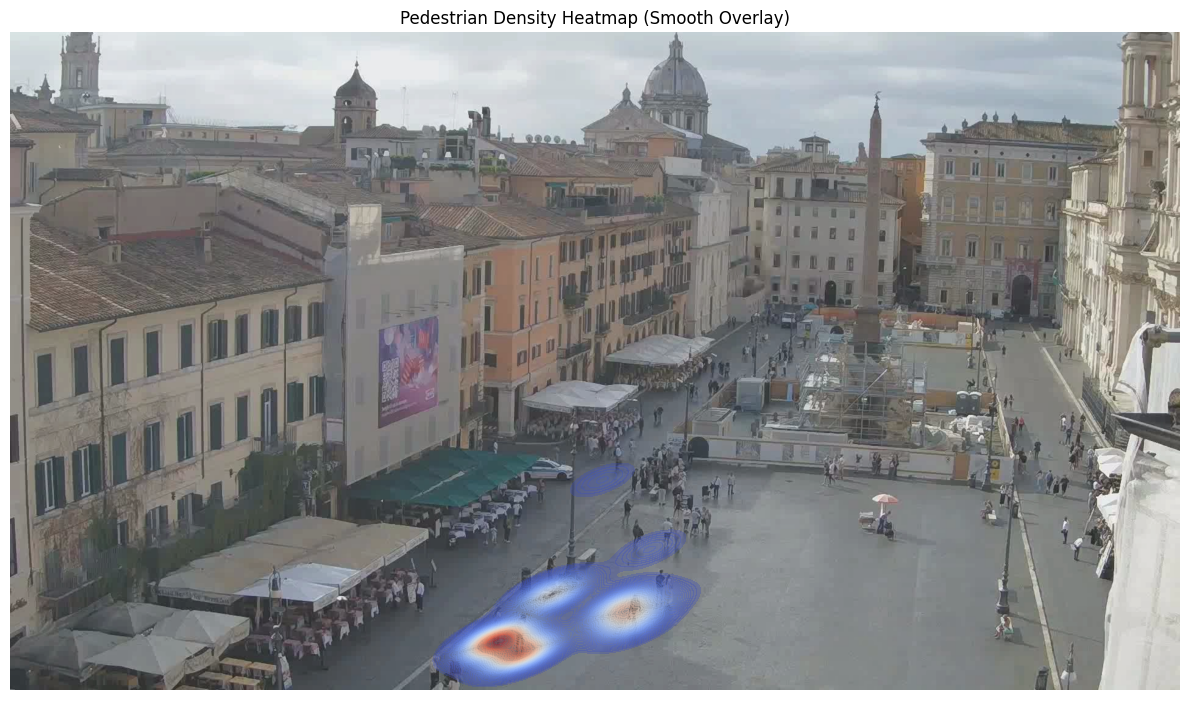

In [10]:
# Visualize pedestrian footprint heatmap

plt.figure(figsize=(12, 9))

# Show background image with transparency
plt.imshow(bg_img, extent=[0, width, height, 0], alpha=0.9)

# KDE heatmap with smooth blending and no white contour lines
sns.kdeplot(
    x=df['x_center'],
    y=df['y_bottom'],
    fill=True,              # fill area under KDE
    cmap="coolwarm",            # smooth color map
    bw_adjust=1.0,          # bandwidth
    levels=100,             # more levels = smoother gradient
    alpha=0.3,              # transparency of the heatmap
    thresh=0.02,            # remove low-density noise
    linewidths=0            # no contour lines (white borders)
)

plt.title("Pedestrian Density Heatmap (Smooth Overlay)")
plt.axis('off')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "viz" / "heatmap_overlay.png", dpi=300)
plt.show()

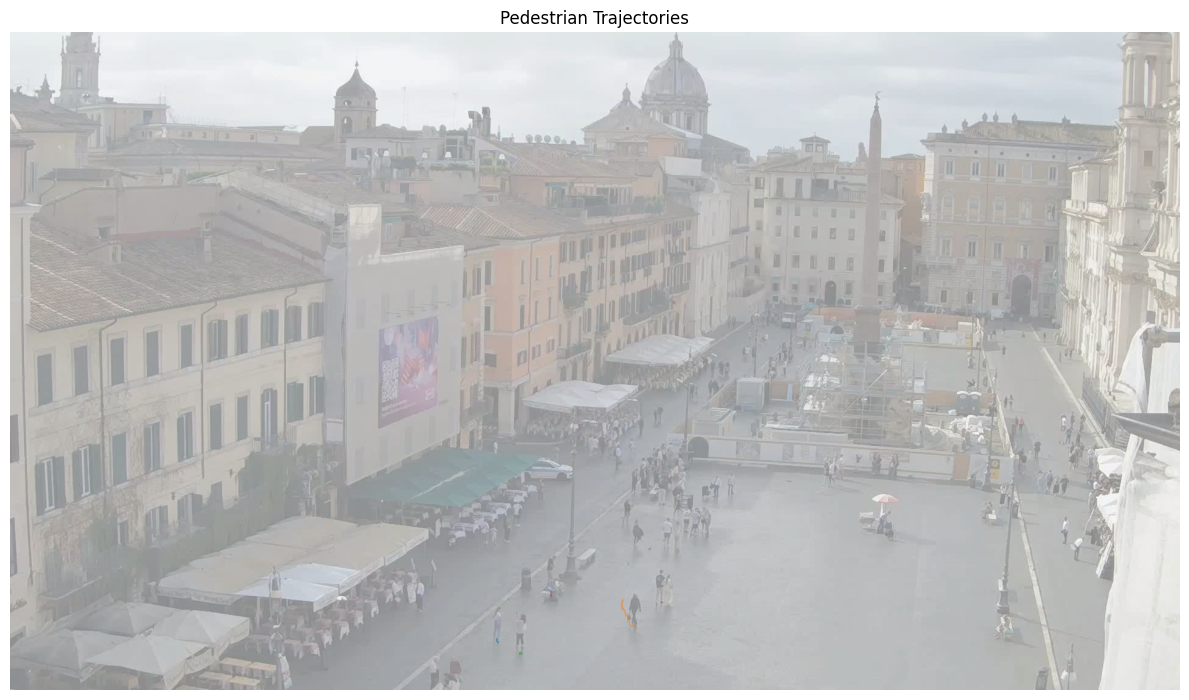

In [11]:
# Pedestrian Trajectories
plt.figure(figsize=(12, 9))

# Show background image
plt.imshow(bg_img, extent=[0, width, height, 0], alpha=0.5)

# Draw each trajectory
for pid, group in df.groupby("id"):
    plt.plot(group['x_center'], group['y_bottom'], linewidth=1, alpha=0.5)

plt.title("Pedestrian Trajectories")
plt.axis('off')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "viz" / "trajectory_overlay.png", dpi=300)
plt.show()

### Read the heatmap and paths

A bright area means more detected foot points in this short clip, not more unique pedestrians. Follow one trajectory back to its ID and boxes; gaps or jumps can reflect missed detections and occlusion.


## Step 5: Optional rendered trajectory clip

In [12]:
# Rendering is optional because it writes a video; keep generated media local and ignored.
RUN_RENDERED_CLIP = False
if RUN_RENDERED_CLIP:
    from visualize_trajectories import visualize_video

In [13]:
if RUN_RENDERED_CLIP:
    visualize_video(
        input_csv=str(analysis_csv),
        input_video=str(analysis_video),
        output_video=str(OUTPUT_DIR / "viz" / f"{analysis_video.stem}_viz.mp4"),
        show_window=False
    )
else:
    print("Rendered clip disabled; frame table and still visualisations are sufficient for smoke QA.")

Rendered clip disabled; frame table and still visualisations are sufficient for smoke QA.
